g:\D\Anaconda\envs\cuda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Determining Device ---
CUDA available. Using GPU 0: NVIDIA GeForce RTX 3070 Laptop GPU (cuda:0)
------------------------------------

--- Initializing Haystack Components ---
Milvus connected: 21350 docs.
Elasticsearch connected: 18375 docs.
Embedder initialized.
Initialized Milvus Retriever (top_k=7)
Initialized BM25 Retriever (top_k=7)
Initialized Document Joiner.


ChatPromptBuilder has 7 prompt variables, but `required_variables` is not set. By default, all prompt variables are treated as optional, which may lead to unintended behavior in multi-branch pipelines. To avoid unexpected execution, ensure that variables intended to be required are explicitly set in `required_variables`.


Ranker initialized (top_k=5).
Memory components initialized.
Initialized ChatPromptBuilder.
Initialized Adapters.
Initialized Main Ollama Generator.
Initialized Answer Builder.
-------------------------------------

--- Building Pipeline (No Document Filter Component) ---


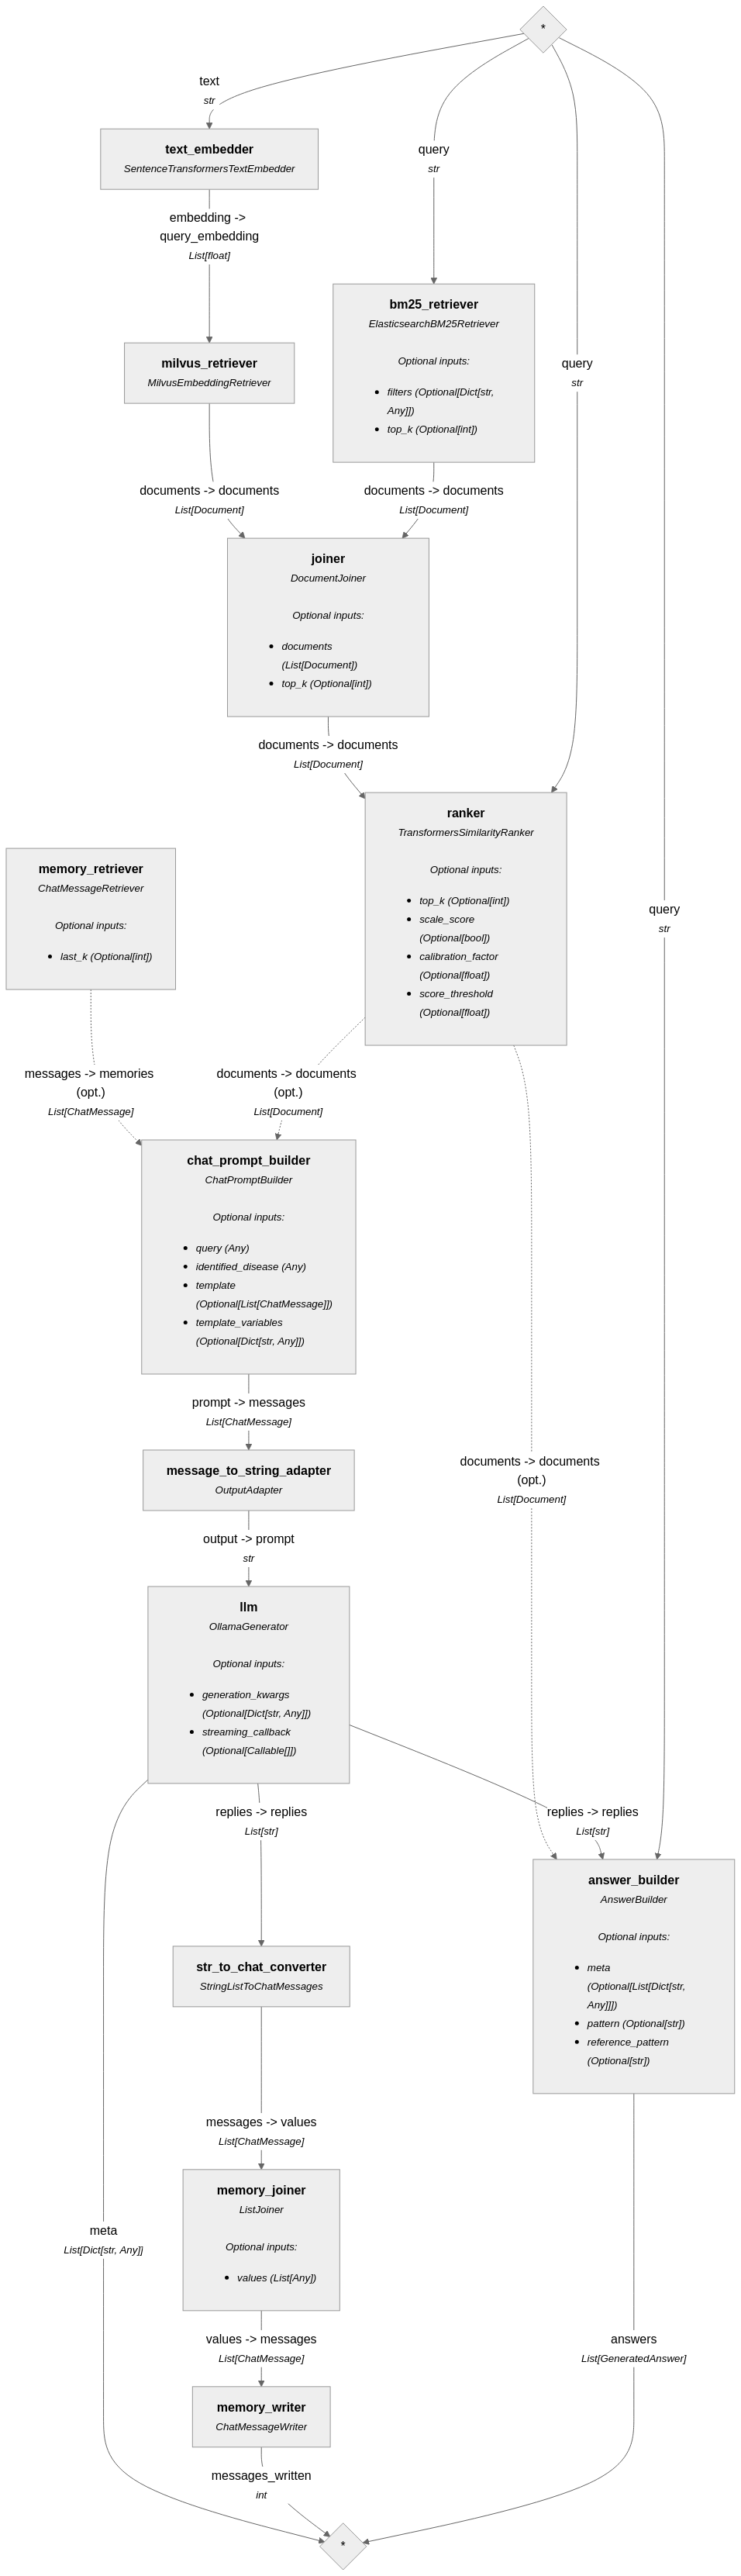

Pipeline built successfully (without doc_filter).
-----------------------------


--- Starting Conversation ---
Nhập 'quit' hoặc 'exit' để kết thúc.
Định dạng gợi ý khi có Vision: <Câu hỏi>? ( <Tên bệnh từ Vision> )


In [ ]:
import torch
import os
import time
import traceback
from typing import List, Any, Optional, Dict
from dotenv import load_dotenv
# --- Haystack Core & Standard Components ---
from haystack import Pipeline, Document, component
from haystack.components.builders import AnswerBuilder, ChatPromptBuilder
from haystack.utils import Secret, ComponentDevice
from haystack.components.embedders import SentenceTransformersTextEmbedder
from haystack.components.joiners import DocumentJoiner, ListJoiner
from haystack.components.rankers import TransformersSimilarityRanker
from haystack.dataclasses import ChatMessage
from haystack.components.converters import OutputAdapter

# --- Haystack Integrations ---
from haystack_integrations.components.generators.ollama import OllamaGenerator
from milvus_haystack import MilvusDocumentStore, MilvusEmbeddingRetriever
from haystack_integrations.document_stores.elasticsearch import ElasticsearchDocumentStore
from haystack_integrations.components.retrievers.elasticsearch import ElasticsearchBM25Retriever

# --- Haystack Experimental (Memory) ---
from haystack_experimental.chat_message_stores.in_memory import InMemoryChatMessageStore
from haystack_experimental.components.retrievers import ChatMessageRetriever
from haystack_experimental.components.writers import ChatMessageWriter
import re

# --- Custom Components ---
@component
class StringListToChatMessages:
    @component.output_types(messages=List[ChatMessage])
    def run(self, replies: List[str]):
        return {"messages": [ChatMessage.from_assistant(reply) for reply in replies]}

# --- Cấu hình ---
load_dotenv()
hf_token = os.getenv("HF_TOKEN")
HF_TOKEN = Secret.from_token(hf_token) if hf_token else None
EXPECTED_EMBEDDING_DIM = 384
MILVUS_URI = "http://localhost:19530"
COLLECTION_NAME = "rag_blocks"
VECTOR_FIELD_NAME = "embedding"
TEXT_FIELD_NAME_MILVUS = "content"
MILVUS_INDEX_PARAMS = {"index_type": "DISKANN", "metric_type": "COSINE", "params": {"search_list": 100}}
MILVUS_SEARCH_PARAMS = {"metric_type": "COSINE", "params": {"search_list": 100}}
MILVUS_TOP_K = 7
ES_HOST = "http://127.0.0.1:9200"
ES_INDEX_NAME = "my_rag_index"
ES_BM25_TOP_K = 7
RANKER_MODEL_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"
RANKER_FINAL_TOP_K = 5
OLLAMA_MODEL_NAME = "llama3.1:8b-instruct-q8_0"
# OLLAMA_MODEL_NAME = "llama3.1:8b-instruct-q6_K"
OLLAMA_URL = "http://localhost:11434"
OLLAMA_TIMEOUT = 180

# --- Xác định Device ---
print("--- Determining Device ---")
if torch.cuda.is_available() and torch.cuda.device_count() > 0:
    try:
        gpu_id = 0
        gpu_name = torch.cuda.get_device_name(gpu_id)
        gpu_device_str = f"cuda:{gpu_id}"
        device = ComponentDevice.from_str(gpu_device_str)
        print(f"CUDA available. Using GPU {gpu_id}: {gpu_name} ({device.to_torch_str()})")
    except Exception as e:
        print(f"CUDA error: {e}. Using CPU.")
        device = ComponentDevice.from_str("cpu")
else:
    device = ComponentDevice.from_str("cpu")
    print("CUDA not available. Using CPU.")
print("------------------------------------\n")


# --- 2. Khởi tạo Haystack Components ---
print("--- Initializing Haystack Components ---")

# -- Document Stores --
try:
    milvus_document_store = MilvusDocumentStore(
        connection_args={"uri": MILVUS_URI}, collection_name=COLLECTION_NAME,
        vector_field=VECTOR_FIELD_NAME, text_field=TEXT_FIELD_NAME_MILVUS,
        index_params=MILVUS_INDEX_PARAMS, search_params=MILVUS_SEARCH_PARAMS
    )
    print(f"Milvus connected: {milvus_document_store.count_documents()} docs.")
except Exception as e: print(f"Error connecting to Milvus: {e}"); exit()

try:
    es_document_store = ElasticsearchDocumentStore(hosts=[ES_HOST], index=ES_INDEX_NAME)
    print(f"Elasticsearch connected: {es_document_store.count_documents()} docs.")
except Exception as e: print(f"Error connecting to Elasticsearch: {e}"); exit()

# -- Embedder --
try:
    text_embedder = SentenceTransformersTextEmbedder(model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", device=device, normalize_embeddings=True)
    text_embedder.warm_up()
    print("Embedder initialized.")
except Exception as e: print(f"Error initializing Embedder: {e}"); exit()

# -- Retrievers --
try:
    milvus_retriever = MilvusEmbeddingRetriever(document_store=milvus_document_store, top_k=MILVUS_TOP_K)
    print(f"Initialized Milvus Retriever (top_k={MILVUS_TOP_K})")
except Exception as e: print(f"Error initializing Milvus Retriever: {e}"); exit()

try:
    bm25_retriever = ElasticsearchBM25Retriever(document_store=es_document_store, top_k=ES_BM25_TOP_K)
    print(f"Initialized BM25 Retriever (top_k={ES_BM25_TOP_K})")
except Exception as e: print(f"Error initializing BM25 Retriever: {e}"); exit()

# -- Joiner --
joiner = DocumentJoiner(join_mode="concatenate")
print("Initialized Document Joiner.")

# -- Ranker --
try:
    ranker = TransformersSimilarityRanker(model=RANKER_MODEL_NAME, top_k=RANKER_FINAL_TOP_K, token=HF_TOKEN, device=device)
    ranker.warm_up()
    print(f"Ranker initialized (top_k={RANKER_FINAL_TOP_K}).")
except Exception as e: print(f"Error initializing Ranker: {e}"); exit()

# -- Memory Components --
memory_store = InMemoryChatMessageStore()
memory_retriever = ChatMessageRetriever(memory_store)
memory_writer = ChatMessageWriter(memory_store)
memory_joiner = ListJoiner(List[ChatMessage])
print("Memory components initialized.")

# -- Chat Prompt Builder --
chat_prompt_template = [
    ChatMessage.from_system(
        "You are a Vietnamese agricultural AI assistant. Your mission is to provide accurate and helpful agricultural information to Vietnamese users. STRICTLY ADHERE to the following rules IN THE CORRECT ORDER:"
        "\n"
        "**RULE 1: PRIORITIZE HANDLING 'HEALTHY' IMAGE RESULTS**"
        "\n"
        "*   **DECISIVE CONDITION:** The `**Image Analysis Result:**` line exists AND it contains ONE OF THE FOLLOWING KEYWORDS: 'khỏe mạnh', 'healthy', 'không có bệnh', 'bình thường'."
        "*   **MANDATORY AND SOLE ACTION (If DECISIVE CONDITION is TRUE):**"
        "    1.  **COMPLETELY IGNORE EVERYTHING ELSE:** Do NOT read, consider, or use `{{ query }}`, `{{ memories }}`, and **POSITIVELY DO NOT LOOK AT or USE any content from `{{ documents }}`**. They are irrelevant and FORBIDDEN in this case."
        "    2.  Reply with EXACTLY and ONLY the following sentence in VIETNAMESE: 'Kết quả phân tích hình ảnh cho thấy cây trồng này khỏe mạnh, không có dấu hiệu bệnh rõ ràng.'"
        "    3.  **STOP IMMEDIATELY.** Do not execute any other Rules."
        "\n"
        "--- Only execute the rules below IF RULE 1 WAS NOT TRIGGERED ---"
        "\n"
        "**RULE 2: HANDLE OTHER (NON-'HEALTHY') IMAGE RESULTS**"
        "\n"
        "*   **CONDITION:** The `**Image Analysis Result:**` line exists AND it does NOT contain any keywords listed in Rule 1."
        "*   **ACTION:**"
        "    *   Identify the disease/issue from `**Image Analysis Result:**` (This is the **Current Context**)."
        "    *   Answer `{{ query }}` focusing on this **Current Context**."
        "    *   **ONLY** use `{{ documents }}` if they are directly relevant to the **Current Context**. Ignore all irrelevant documents."
        "    *   Avoid video links."
        "    *   Stop."
        "\n"
        "--- Only execute the rules below IF RULE 1 AND RULE 2 DID NOT APPLY ---"
        "\n"
        "**RULE 3: CHECK FOR OFF-TOPIC QUERIES (NO IMAGE)**"
        "\n"
        "*   **CONDITION:** No `**Image Analysis Result:**` exists AND `{{ query }}` is clearly NOT related to agriculture, plants, pests, diseases, fertilizers, or farming techniques (e.g., asking about politics, history, unrelated cooking, celebrities, world news, etc.)."
        "*   **MANDATORY ACTION:**"
        "    1.  **ABSOLUTELY DO NOT USE `{{ documents }}`.**"
        "    2.  Politely reply in VIETNAMESE that you are an agricultural assistant and cannot answer off-topic questions. Example: 'Tôi là trợ lý AI chuyên về nông nghiệp Việt Nam. Rất tiếc, tôi không thể trả lời câu hỏi của bạn về chủ đề này. Bạn có câu hỏi nào khác liên quan đến trồng trọt, sâu bệnh hoặc kỹ thuật nông nghiệp không?'"
        "    3.  **STOP IMMEDIATELY.** Do not execute Rule 4."
        "\n"
        "--- Only execute the rule below IF RULE 1, 2, AND 3 DID NOT APPLY ---"
        "\n"
        "**RULE 4: ANSWER NORMAL AGRICULTURAL QUERIES (NO IMAGE, ON-TOPIC)**"
        "\n"
        "*   **CONDITION:** No `**Image Analysis Result:**` exists AND `{{ query }}` is related to agriculture."
        "*   **ACTION:**"
        "    *   Check `{{ memories }}` for a recently discussed **Context** (disease/topic)."
        "    *   Answer `{{ query }}`: prioritize the **Context** (if available), otherwise answer generally."
        "    *   Use `{{ documents }}` to find information relevant to the **Context** (if available) or directly relevant to `{{ query }}`."
        "    *   Avoid video links."
        "\n"
        "**MOST CRITICAL REMINDERS:**"
        "\n"
        "1.  **ADHERE TO RULE ORDER: 1 -> 2 -> 3 -> 4.**"
        "2.  **ALWAYS RESPOND IN VIETNAMESE.** THIS IS MANDATORY."
        "3.  **RULE 1 IS ABSOLUTE:** When triggered, it overrides everything else and FORBIDS document usage."
        "4.  **RULE 3 ALSO FORBIDS DOCUMENT USAGE** for off-topic questions."
        "5.  Maintain **Context** once identified in Rule 2 or 4 for follow-up turns."
    ),
    ChatMessage.from_user(
         """**Chat History:**
{% for msg in memories %}
{% if msg.role == 'user' %}User: {{ (msg.to_dict()).content[0].text }}{% elif msg.role == 'assistant' %}Assistant: {{ (msg.to_dict()).content[0].text }}{% endif %}
{% else %}
(No chat history)
{% endfor %}

{% if identified_disease %}
**Image Analysis Result:** {{ identified_disease }}
{% endif %}

**Reference Documents:**
{% if documents %}
    {% for doc in documents %}
    ---
    {{ doc.content }}
    ---
    {% endfor %}
{% else %}
    (No reference documents)
{% endif %}

**User's Current Question:** {{ query }}

**Answer (Strictly follow ALL rules and critical reminders, RESPOND ONLY IN VIETNAMESE):**"""
    )
]
chat_prompt_builder = ChatPromptBuilder(template=chat_prompt_template)
print("Initialized ChatPromptBuilder.")

# -- Adapters cho LLM và Memory --
message_to_string_adapter = OutputAdapter(template="{{ (messages[-1].to_dict())['content'][0]['text'] }}", output_type=str)
str_to_chat_converter = StringListToChatMessages()
print("Initialized Adapters.")

# -- LLM Generator (chính) --
try:
    llm_generator = OllamaGenerator(model=OLLAMA_MODEL_NAME, url=OLLAMA_URL, timeout=OLLAMA_TIMEOUT, generation_kwargs={"num_predict": 700, "temperature": 0.7, "top_p": 0.9})
    print("Initialized Main Ollama Generator.")
except Exception as e: print(f"Error initializing Main Ollama Generator: {e}"); exit()

# -- Answer Builder --
answer_builder = AnswerBuilder()
print("Initialized Answer Builder.")
print("-------------------------------------\n")

# --- 3. Xây dựng Pipeline ---
print("--- Building Pipeline (No Document Filter Component) ---")
pipeline = Pipeline()

# Thêm components
pipeline.add_component("memory_retriever", memory_retriever)
pipeline.add_component("text_embedder", text_embedder)
pipeline.add_component("milvus_retriever", milvus_retriever)
pipeline.add_component("bm25_retriever", bm25_retriever)
pipeline.add_component("joiner", joiner)
pipeline.add_component("ranker", ranker)
pipeline.add_component("chat_prompt_builder", chat_prompt_builder)
pipeline.add_component("message_to_string_adapter", message_to_string_adapter)
pipeline.add_component("llm", llm_generator)
pipeline.add_component("str_to_chat_converter", str_to_chat_converter)
pipeline.add_component("memory_joiner", memory_joiner)
pipeline.add_component("memory_writer", memory_writer)
pipeline.add_component("answer_builder", answer_builder)

# --- Kết nối Pipeline ---
pipeline.connect("text_embedder.embedding", "milvus_retriever.query_embedding")
pipeline.connect("milvus_retriever.documents", "joiner.documents")
pipeline.connect("bm25_retriever.documents", "joiner.documents")
pipeline.connect("joiner.documents", "ranker.documents")
pipeline.connect("ranker.documents", "chat_prompt_builder.documents")
pipeline.connect("memory_retriever.messages", "chat_prompt_builder.memories")
pipeline.connect("chat_prompt_builder.prompt", "message_to_string_adapter.messages")
pipeline.connect("message_to_string_adapter.output", "llm.prompt")
pipeline.connect("llm.replies", "str_to_chat_converter.replies")
pipeline.connect("str_to_chat_converter.messages", "memory_joiner.values")
pipeline.connect("memory_joiner.values", "memory_writer.messages")
pipeline.connect("llm.replies", "answer_builder.replies")
pipeline.connect("ranker.documents", "answer_builder.documents")

pipeline.show()
print("Pipeline built successfully (without doc_filter).")
print("-----------------------------\n")
# --- 4. Chạy Pipeline ---
print("\n--- Starting Conversation ---")
print("Nhập 'quit' hoặc 'exit' để kết thúc.")
print("Định dạng gợi ý khi có Vision: <Câu hỏi>? ( <Tên bệnh từ Vision> )")

while True:
    user_input_raw = input("🧑 User: ")
    if user_input_raw.lower() in ["quit", "exit"]:
        break

    original_query = user_input_raw
    disease_name = None
    # Đơn giản chỉ trích xuất disease_name nếu có
    match = re.search(r'\(([^)]+)\)\s*$', user_input_raw)
    if match:
        disease_name = match.group(1).strip()

    # Pipeline Input sử dụng original_query cho RAG
    pipeline_input = {
        "text_embedder": {"text": original_query},   # Luôn dùng original_query
        "bm25_retriever": {"query": original_query}, # Luôn dùng original_query
        "ranker": {"query": original_query},         # Luôn dùng original_query
        "chat_prompt_builder": {
            "query": original_query,        # Gửi query gốc
            "identified_disease": disease_name # Gửi disease_name (có thể là None)
        },
        "memory_joiner": {"values": [ChatMessage.from_user(original_query)]},
        "answer_builder": {"query": original_query}
    }
    try:
        start_run_time = time.time()
        result = pipeline.run(pipeline_input, include_outputs_from=["answer_builder"])
        end_run_time = time.time()

        if "answer_builder" in result and result["answer_builder"]["answers"]:
            final_answer = result["answer_builder"]["answers"][0]
            print(f"🤖 Assistant: {final_answer.data}")
        else:
            print("🤖 Assistant: Xin lỗi, tôi không thể tạo câu trả lời.")

    except Exception as e:
        print(f"\n--- An error occurred ---")
        print(e)
        traceback.print_exc()

print("\n------------------------")
print("Conversation finished.")